# Digit Recognition for Optical Sudoku Solver

This notebook trains a Support Vector Machine (SVM) classifier to recognize printed digits (1–9) from extracted Sudoku cell images.

**Pipeline:**
1. Download and prepare the Chars74K `EnglishFnt` dataset
2. Preprocess images and extract HOG features
3. Train and evaluate an SVM classifier
4. Export the trained model to `models/digit_model.pkl`

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import joblib

from utils import normalize_cell, HOG_PARAMS, extract_hog_features, extract_lbp_features, extract_features

In [2]:
# ── Data source selection ───────────────────────────────────────────────────
# "chars74k" : Chars74K EnglishFnt computer fonts only
# "sudoku"   : Mined labeled cells from the Sudoku dataset only
# "both"     : Combine both sources (recommended)
DATA_SOURCE = "sudoku"

# Paths (used conditionally below)
CHARS74K_PATH = os.path.join("data", "English", "Fnt")
SUDOKU_DATASET_PATH = os.path.join("data", "sudoku_dataset", "images")

## 1. Dataset Setup

The [Chars74K](http://www.ee.surrey.ac.uk/CVSSP/demos/chars74k/) dataset contains computer-rendered characters across 1,016 fonts. We use the `EnglishFnt` subset, which covers digits and letters in clean typeset form — well-matched to printed Sudoku puzzles.

The cell below downloads and extracts the dataset into `data/` automatically if it is not already present.

In [3]:
if DATA_SOURCE != "sudoku":
    DATASET_URL = "http://www.ee.surrey.ac.uk/CVSSP/demos/chars74k/EnglishFnt.tgz"
    ARCHIVE_PATH = os.path.join("data", "EnglishFnt.tgz")

    def download_progress(block_num, block_size, total_size):
        downloaded = block_num * block_size
        percent = min(downloaded / total_size * 100, 100)
        print(f"\rDownloading Chars74K... {percent:.1f}%", end="", flush=True)

    if not os.path.exists(CHARS74K_PATH):
        os.makedirs("data", exist_ok=True)
        print("Downloading Chars74K EnglishFnt dataset...")
        urllib.request.urlretrieve(DATASET_URL, ARCHIVE_PATH, reporthook=download_progress)
        print("\nExtracting...")
        with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
            tar.extractall("data")
        os.remove(ARCHIVE_PATH)
        print(f"Chars74K ready at: {CHARS74K_PATH}")
    else:
        print(f"Chars74K already present at: {CHARS74K_PATH}")

if DATA_SOURCE != "chars74k":
    import subprocess
    if not os.path.exists(SUDOKU_DATASET_PATH):
        os.makedirs("data", exist_ok=True)
        print("Cloning Sudoku dataset...")
        result = subprocess.run(
            ["git", "clone", "--depth=1",
             "https://github.com/wichtounet/sudoku_dataset.git",
             os.path.join("data", "sudoku_dataset")],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print(f"Sudoku dataset ready at: {SUDOKU_DATASET_PATH}")
        else:
            print(f"Clone failed: {result.stderr}")
    else:
        print(f"Sudoku dataset already present at: {SUDOKU_DATASET_PATH}")

Cloning Sudoku dataset...
Sudoku dataset ready at: data/sudoku_dataset/images


In [4]:
# ── Rotation fix for known mis-oriented images in the Sudoku dataset ─────────
# 9 images (<5% of dataset) were captured in the wrong orientation.
# This cell corrects them once and writes a sentinel file so re-running is safe.
# Note: users running only Image_Processing.ipynb with a pre-trained model
# are unaffected — these images are training/evaluation data only.

if DATA_SOURCE != "chars74k":
    SENTINEL = os.path.join("data", "sudoku_dataset", ".rotations_applied")

    ROTATIONS = {
        "image1024.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
        "image1031.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
        "image1036.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
        "image1038.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
        "image1039.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
        "image1040.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
        "image1041.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
        "image1043.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
        "image1083.jpg": cv2.ROTATE_180,
    }

    if os.path.exists(SENTINEL):
        print("Rotation fixes already applied, skipping.")
    else:
        fixed = 0
        for fname, rotation in ROTATIONS.items():
            path = os.path.join(SUDOKU_DATASET_PATH, fname)
            if os.path.exists(path):
                img = cv2.imread(path)
                cv2.imwrite(path, cv2.rotate(img, rotation))
                print(f"Fixed: {fname}")
                fixed += 1
            else:
                print(f"Not found (skipping): {fname}")
        open(SENTINEL, "w").close()
        print(f"\n{fixed} image(s) corrected. Sentinel written to {SENTINEL}")

Fixed: image1024.jpg
Fixed: image1031.jpg
Fixed: image1036.jpg
Fixed: image1038.jpg
Fixed: image1039.jpg
Fixed: image1040.jpg
Fixed: image1041.jpg
Fixed: image1043.jpg
Fixed: image1083.jpg

9 image(s) corrected. Sentinel written to data/sudoku_dataset/.rotations_applied


## 2. Data Loading and Preprocessing

Depending on `DATA_SOURCE`, we load from one or both of:

- **Chars74K `EnglishFnt`** — 1,016 computer-rendered fonts × 9 digits = 9,144 images
- **Sudoku dataset** — labeled cells mined from real puzzle images using ground-truth `.dat` files

All images are resized to **40×40 pixels** (matching `Image_Processing.ipynb` output) and passed through `normalize_cell()` to center the digit on a clean canvas before feature extraction.

In [5]:
CELL_SIZE = 40  # must match the cell size produced by Image_Processing.ipynb

images = []
labels = []

# ── Chars74K ────────────────────────────────────────────────────────────────
# Sample001 = '0', Sample002 = '1', ..., Sample010 = '9'
if DATA_SOURCE != "sudoku":
    DIGIT_SAMPLES = {digit: f"Sample{digit + 1:03d}" for digit in range(1, 10)}

    for digit, sample_folder in DIGIT_SAMPLES.items():
        folder_path = os.path.join(CHARS74K_PATH, sample_folder)
        for fname in sorted(os.listdir(folder_path)):
            if not fname.endswith(".png"):
                continue
            img = cv2.imread(os.path.join(folder_path, fname), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (CELL_SIZE, CELL_SIZE))
            img = normalize_cell(img)
            if img.max() == 0:  # normalization failed — faint/empty glyph, skip
                continue
            images.append(img)
            labels.append(digit)

    print(f"Chars74K samples loaded: {len(images)}")

In [6]:
# ── Sudoku dataset mining ────────────────────────────────────────────────────
from utils import parse_dat_file, extract_cells_for_training

if DATA_SOURCE != "chars74k":
    all_files = sorted([
        f for f in os.listdir(SUDOKU_DATASET_PATH) if f.endswith(".jpg")
    ])

    # Puzzle-level 80/20 train/test split (fixed seed for reproducibility)
    rng_split = np.random.default_rng(seed=42)
    shuffled = rng_split.permutation(all_files).tolist()
    split_idx = int(len(shuffled) * 0.8)
    train_files = shuffled[:split_idx]
    test_files  = shuffled[split_idx:]

    # Persist test filenames for Evaluation.ipynb
    with open(os.path.join("data", "test_puzzles.txt"), "w") as f:
        f.write("\n".join(test_files))

    print(f"Train puzzles : {len(train_files)}")
    print(f"Test puzzles  : {len(test_files)}  (saved to data/test_puzzles.txt)")

    skipped = 0
    before  = len(images)

    for fname in train_files:
        image_path = os.path.join(SUDOKU_DATASET_PATH, fname)
        dat_path   = image_path.replace(".jpg", ".dat")

        if not os.path.exists(dat_path):
            skipped += 1
            continue

        cells = extract_cells_for_training(image_path, cell_size=CELL_SIZE)
        if cells is None:
            skipped += 1
            continue

        grid = parse_dat_file(dat_path)

        for row in range(9):
            for col in range(9):
                digit = grid[row][col]
                if digit == 0:
                    continue  # empty cell — no label
                cell_img = normalize_cell(cells[row * 9 + col])
                if cell_img.max() == 0:  # normalization failed — skip
                    continue
                images.append(cell_img)
                labels.append(digit)

    print(f"\nSudoku samples added : {len(images) - before}")
    print(f"Images skipped       : {skipped}")

print(f"\nTotal samples before augmentation: {len(images)}")

images = np.array(images)
labels = np.array(labels)

Train puzzles : 162
Test puzzles  : 41  (saved to data/test_puzzles.txt)

Sudoku samples added : 2472
Images skipped       : 55

Total samples before augmentation: 2472


### Data Augmentation

To bridge the gap between clean Chars74K fonts and real scanned Sudoku images, we generate **3 augmented copies** of every training image — giving 4× the training data (~36,576 samples total).

Each augmented copy randomly applies rotation, erosion/dilation, Gaussian blur, and salt-and-pepper noise via `augment_image()` from `utils.py`.

In [7]:
from utils import augment_image

AUGMENTATIONS_PER_IMAGE = 3
rng = np.random.default_rng(seed=42)

aug_images = []
aug_labels = []

for img, label in zip(images, labels):
    for _ in range(AUGMENTATIONS_PER_IMAGE):
        aug_images.append(augment_image(img, rng=rng))
        aug_labels.append(label)

images = np.concatenate([images, np.array(aug_images)])
labels = np.concatenate([labels, np.array(aug_labels)])

print(f"Total samples after augmentation: {len(images)}")
print(f"Samples per digit: {len(images) // 9}")

Total samples after augmentation: 9888
Samples per digit: 1098


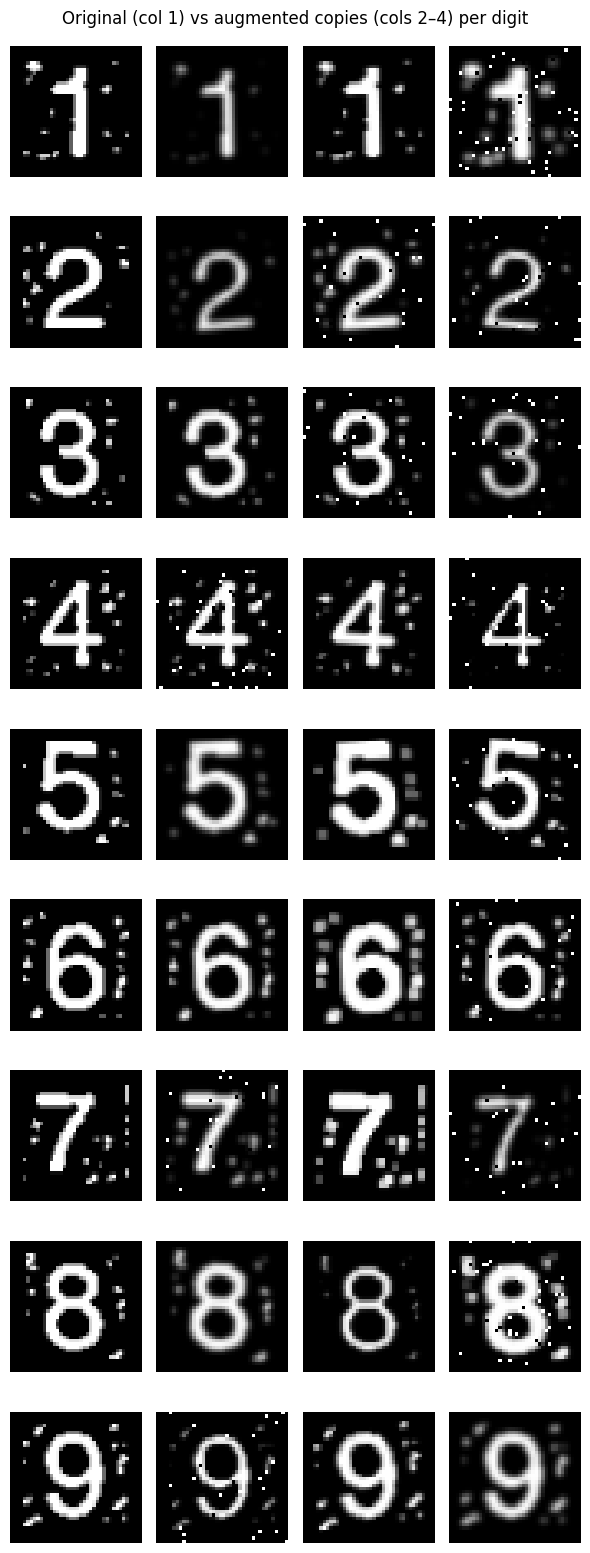

In [8]:
# Show original vs 3 augmented versions for one sample of each digit
fig, axes = plt.subplots(9, 4, figsize=(6, 16))
fig.suptitle("Original (col 1) vs augmented copies (cols 2–4) per digit", fontsize=12)

vis_rng = np.random.default_rng(seed=0)
for row, digit in enumerate(range(1, 10)):
    digit_indices = np.where(labels == digit)[0]
    # Pick the first non-black sample for a clean visualization
    idx = next((i for i in digit_indices if images[i].max() > 0), digit_indices[0])
    original = images[idx]
    axes[row, 0].imshow(original, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_ylabel(str(digit), fontsize=11, rotation=0, labelpad=12)
    axes[row, 0].axis("off")
    for col in range(1, 4):
        aug = augment_image(original, rng=vis_rng)
        axes[row, col].imshow(aug, cmap="gray", vmin=0, vmax=255)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

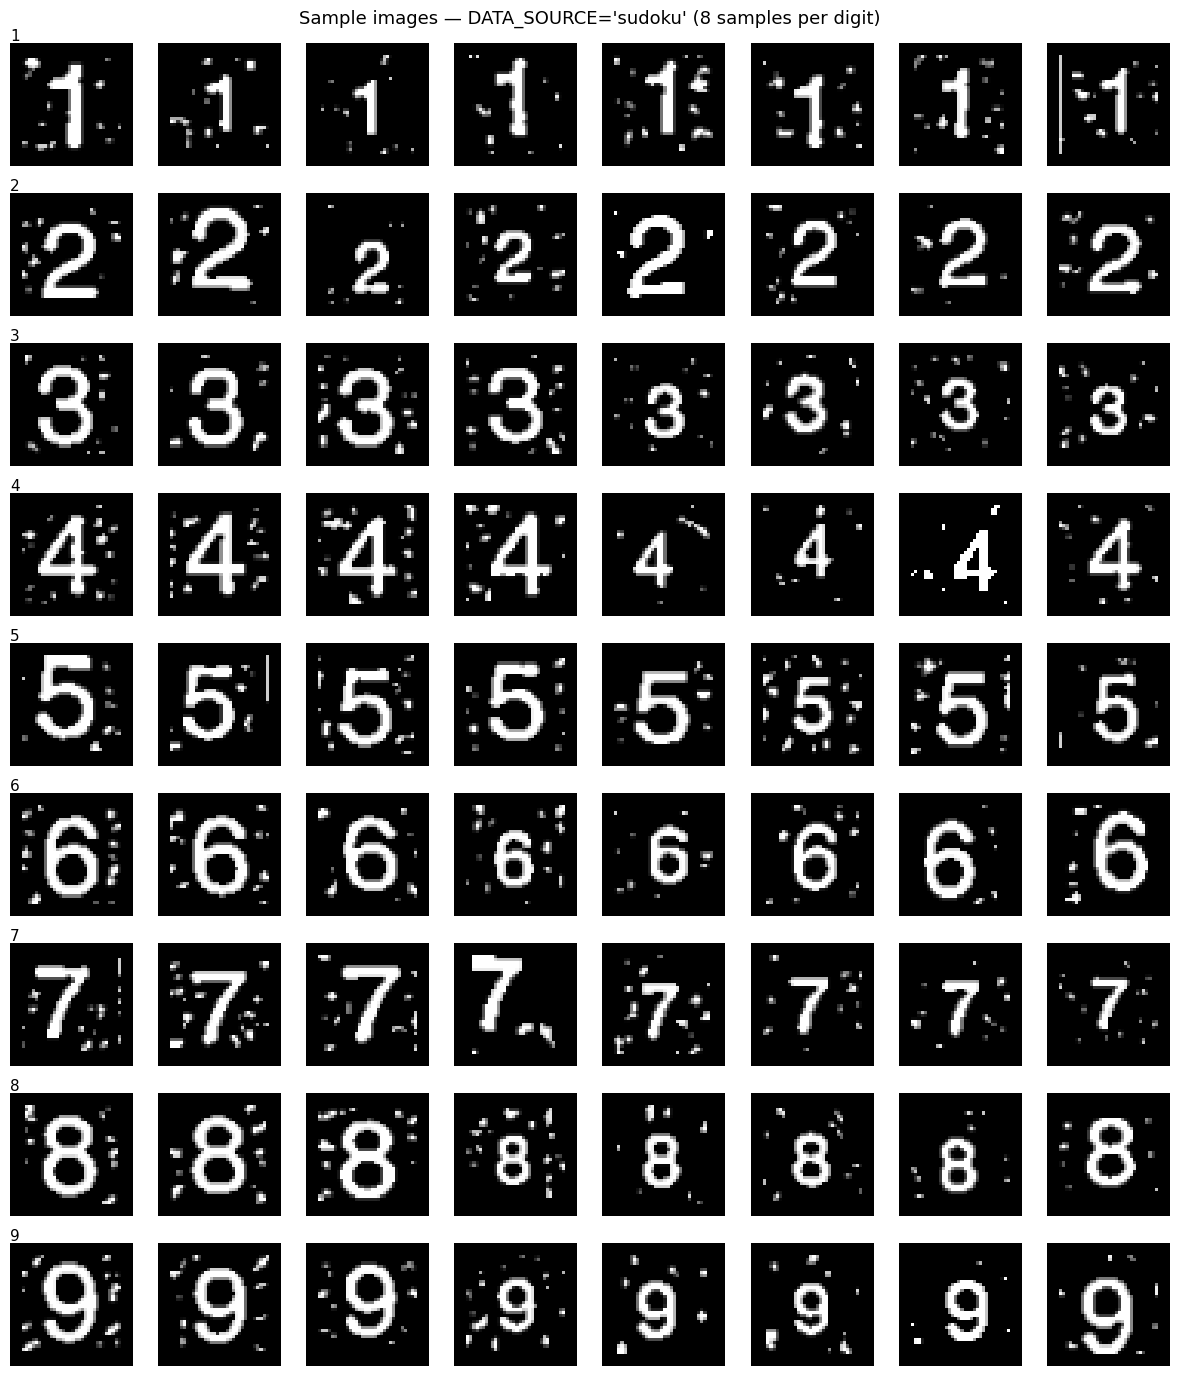

In [9]:
fig, axes = plt.subplots(9, 8, figsize=(12, 14))
fig.suptitle(f"Sample images — DATA_SOURCE='{DATA_SOURCE}' (8 samples per digit)", fontsize=13)

for row, digit in enumerate(range(1, 10)):
    digit_indices = np.where(labels == digit)[0]
    sample_indices = digit_indices[:8]
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(images[idx], cmap="gray", vmin=0, vmax=255)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(str(digit), fontsize=11, loc="left", pad=2)

plt.tight_layout()
plt.show()

## 3. Feature Extraction — HOG + LBP

We combine two complementary feature descriptors to improve discrimination between visually similar digits (3, 6, 8, 9):

**HOG (Histogram of Oriented Gradients)** — captures edge directions and shape structure.
- `pixels_per_cell=(4, 4)` — 10×10 grid of cells on a 40×40 image (finer than 8×8, picks up more local detail)
- `cells_per_block=(2, 2)`, `orientations=9`
- Produces **2,916 features**

**LBP (Local Binary Pattern)** — captures local texture topology (open vs closed loops).
- `P=8, R=1, method="uniform"` — 59 unique pattern bins
- Computed over a 4×4 spatial grid of regions for positional awareness
- Produces **944 features** (4 × 4 × 59)

**Combined feature vector: 3,860 dimensions**

In [10]:
X = extract_features(images)
y = labels

print(f"Feature matrix shape     : {X.shape}")
print(f"HOG features per image   : {extract_hog_features(images[:1]).shape[1]}")
print(f"LBP features per image   : {extract_lbp_features(images[:1]).shape[1]}")
print(f"Combined features/image  : {X.shape[1]}")

Feature matrix shape     : (9888, 3860)
HOG features per image   : 2916
LBP features per image   : 944
Combined features/image  : 3860


### HOG Visualization

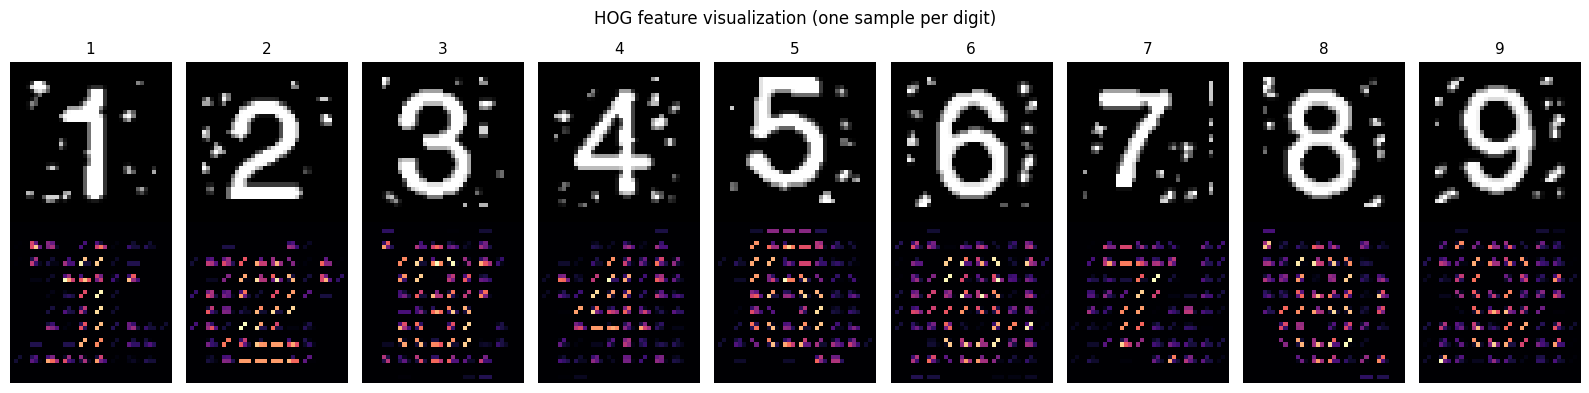

In [11]:
from skimage.feature import hog as skimage_hog

fig, axes = plt.subplots(2, 9, figsize=(16, 4))
fig.suptitle("HOG feature visualization (one sample per digit)", fontsize=12)

for col, digit in enumerate(range(1, 10)):
    digit_indices = np.where(labels == digit)[0]
    # Pick the first non-black sample for a clean visualization
    idx = next((i for i in digit_indices if images[i].max() > 0), digit_indices[0])
    img_norm = images[idx].astype(np.float32) / 255.0
    _, hog_image = skimage_hog(img_norm, **HOG_PARAMS, visualize=True)

    axes[0, col].imshow(images[idx], cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(str(digit), fontsize=11)
    axes[0, col].axis("off")

    axes[1, col].imshow(hog_image, cmap="magma")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("HOG", fontsize=10)
plt.tight_layout()
plt.show()

## 4. Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# Class distribution check
unique, counts = np.unique(y_train, return_counts=True)
print("\nTraining samples per digit:")
for d, c in zip(unique, counts):
    print(f"  Digit {d}: {c}")

Training samples : 7910
Test samples     : 1978

Training samples per digit:
  Digit 1: 870
  Digit 2: 874
  Digit 3: 954
  Digit 4: 803
  Digit 5: 893
  Digit 6: 877
  Digit 7: 915
  Digit 8: 918
  Digit 9: 806


## 5. SVM Training

We train a Support Vector Machine with an **RBF (radial basis function) kernel**. RBF is well-suited for HOG features because it can model the non-linear boundaries between digit classes.

**Hyperparameters:**
- `C=10` — regularization strength; penalizes misclassifications (higher = tighter fit)
- `gamma='scale'` — sets the RBF kernel width automatically based on feature variance

In [13]:
svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(X_train, y_train)
print("SVM training complete.")

SVM training complete.


### Cross-Validation

5-fold cross-validation on the training set gives an unbiased estimate of generalization accuracy before we touch the test set.

In [14]:
# from sklearn.model_selection import cross_val_score

# cv_scores = cross_val_score(svm, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
# print(f"Cross-validation accuracy (5-fold): {cv_scores}")
# print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

### Test Set Evaluation

In [15]:
y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred, target_names=[str(d) for d in range(1, 10)]))

              precision    recall  f1-score   support

           1       0.99      0.99      0.99       218
           2       1.00      0.99      0.99       218
           3       0.99      0.97      0.98       238
           4       1.00      0.99      0.99       201
           5       0.98      0.99      0.98       223
           6       0.98      1.00      0.99       219
           7       0.99      1.00      1.00       229
           8       0.97      0.99      0.98       230
           9       0.99      0.99      0.99       202

    accuracy                           0.99      1978
   macro avg       0.99      0.99      0.99      1978
weighted avg       0.99      0.99      0.99      1978



### Confusion Matrix

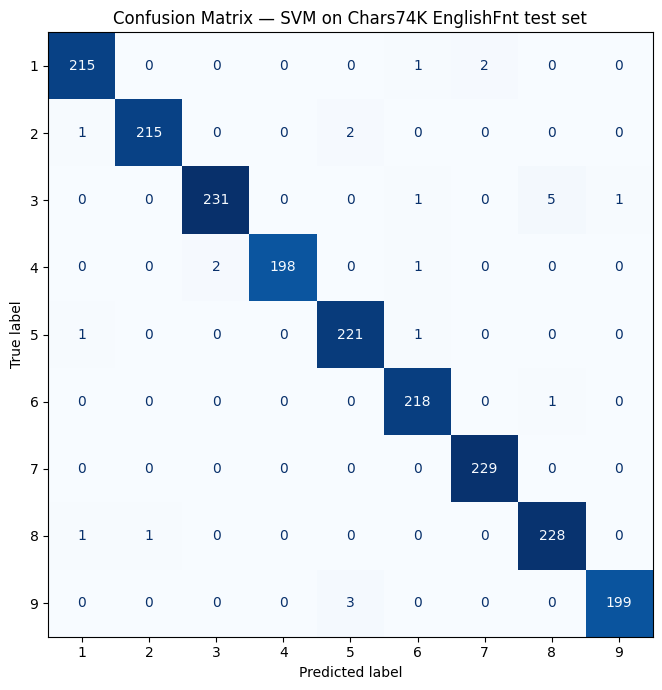

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — SVM on Chars74K EnglishFnt test set")
plt.tight_layout()
plt.show()

## 6. Export Model

Save the trained model to `models/digit_model.pkl` for use in `Image_Processing.ipynb`.

In [17]:
os.makedirs("models", exist_ok=True)
joblib.dump(svm, "models/digit_model.pkl")
print("Model saved to models/digit_model.pkl")

Model saved to models/digit_model.pkl
